# I tre modelli della temperatura — termico, elettrico, casa

Questo notebook mostra **come funzionano** i tre modelli che ruotano attorno alla
temperatura nel simulatore, usando le classi reali della libreria
(`sim_stochastic_pv.simulation.*`):

| # | Modello | Modulo | Cosa produce |
|---|---------|--------|--------------|
| 1 | **Termico** — temperatura *ambiente* | [`thermal.py`](../sim_stochastic_pv/simulation/thermal.py) — `ThermalModel` | serie giornaliera e oraria di T esterna (stagionale + AR(1) + estremi) |
| 2 | **Elettrico** — produzione PV *in funzione della temperatura* | [`electrical.py`](../sim_stochastic_pv/simulation/electrical.py) — `ElectricalModel` | T della cella, derating di potenza, tensione di stringa, shutdown |
| 3 | **Casa** — temperatura *interna* e carico HVAC | [`thermal_load.py`](../sim_stochastic_pv/simulation/thermal_load.py) — `HvacController` | kW elettrici della pompa di calore e temperatura raggiunta in casa |

**Come sono collegati** (vedi `energy_simulator.py`):

```
ThermalModel.simulate_daily_means()  ->  to_hourly()  =>  T_ambient orario (8760 valori)
                                                          |
                          +-------------------------------+-------------------------------+
                          v                                                               v
        ElectricalModel.apply_to_pv_dc(pv_dc, T_amb)            HvacController.compute_hourly_p_elec_kw(T_amb)
        (T_cella via NOCT, derating gamma, finestra MPPT)       (P_th = UA*(T_set - T_amb), P_el = P_th/COP)
```

> **Filo conduttore: una casa isolata male.** Nella Sezione 3 usiamo il preset
> `insulation_preset="poor"` (`UA = 2.5 W/°C/m²`, tipico di una casa anni '60–'70
> senza cappotto) e lo confrontiamo con `"good"` (Classe A). Vedremo che con
> isolamento scadente la pompa di calore **non riesce** a tenere i 20 °C durante
> un'ondata di freddo e i consumi annui triplicano.

## 0 · Setup

Aggiungiamo la root del repo al `sys.path` (così `import sim_stochastic_pv`
funziona sia aprendo il notebook dalla cartella `notebooks/` sia dalla root),
e fissiamo lo stile dei grafici.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

for _cand in (os.getcwd(), os.path.abspath(os.path.join(os.getcwd(), ".."))):
    if os.path.isdir(os.path.join(_cand, "sim_stochastic_pv")):
        sys.path.insert(0, _cand)
        REPO_ROOT = _cand
        break
else:
    raise RuntimeError("Non trovo il pacchetto sim_stochastic_pv: apri il notebook dentro il repo.")

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "axes.titlesize": 11,
})
MESI = ["Gen", "Feb", "Mar", "Apr", "Mag", "Giu", "Lug", "Ago", "Set", "Ott", "Nov", "Dic"]
print("repo root:", REPO_ROOT)

repo root: /Users/francescobazzani/Documents/Progetti/Python/sim_stochastic_pv


## 1 · Modello termico — temperatura ambiente

`ThermalModel` genera la temperatura *esterna* combinando tre componenti
(modulo [`thermal.py`](../sim_stochastic_pv/simulation/thermal.py)):

1. **Media stagionale** — una sinusoide annua:
   $$T_{stag}(d) = a_0 + a_1\cos\!\Big(\tfrac{2\pi d}{365.25}\Big) + a_2\sin\!\Big(\tfrac{2\pi d}{365.25}\Big)$$
   `a0` è la media annua, `√(a1²+a2²)` l'ampiezza stagionale.
2. **Residui AR(1)** — persistenza giorno-su-giorno (i periodi caldi/freddi
   "durano"): $r_d = \phi\, r_{d-1} + \varepsilon_d$, con
   $\sigma_{innov} = \sigma_{res}\sqrt{1-\phi^2}$.
3. **Estremi a coda pesante (GPD/POT)** — ondate di calore (coda superiore) e
   *cold snap* (coda inferiore). Quando scattano, l'AR(1) propaga l'estremo per
   più giorni → il classico "plateau" di un'ondata.

Infine `to_hourly()` aggiunge il **profilo diurno** sinusoidale (picco ~14:00,
minimo ~02:00, ampiezza `t_amplitude_c` del mese).

Costruiamo un clima tipo **Nord Italia collinare** (media annua ~12.5 °C),
con cold snap a Gen/Feb/Dic e ondate di calore a Giu/Lug/Ago.

In [2]:
from sim_stochastic_pv.simulation.thermal import (
    ThermalModel, HarmonicSeasonalMean, ThermalMonthParams, GPDTail,
    simulate_temperature_preview, month_of_year,
)

harmonic = HarmonicSeasonalMean(a0=12.5, a1=-9.5, a2=-2.0)  # media 12.5°C, ampiezza ~9.7°C
std_per_mese = [3.0, 3.0, 2.8, 2.5, 2.3, 2.2, 2.2, 2.3, 2.5, 2.7, 2.9, 3.0]  # sigma residui (°C)
amp_per_mese = [4.0, 4.5, 5.5, 6.0, 6.5, 7.0, 7.5, 7.0, 6.0, 5.0, 4.0, 3.8]  # mezza escursione diurna (°C)
mesi_estivi, mesi_invernali = (5, 6, 7), (0, 1, 11)

monthly = []
for m in range(12):
    upper = GPDTail(threshold=5.0, shape=0.05, scale=2.5, exceedance_prob=0.06) if m in mesi_estivi else None
    lower = GPDTail(threshold=5.0, shape=0.00, scale=2.8, exceedance_prob=0.07) if m in mesi_invernali else None
    monthly.append(ThermalMonthParams(
        t_std_residual_c=std_per_mese[m], persistence_phi=0.80,
        t_amplitude_c=amp_per_mese[m], gpd_upper=upper, gpd_lower=lower,
    ))

thermal = ThermalModel(harmonic, monthly, climate_trend_c_per_year=0.0)

rng = np.random.default_rng(7)
daily_means, eventi = thermal.simulate_daily_means(365, rng, track_events=True)
T_amb_hourly = thermal.to_hourly(daily_means)   # (8760,) — RIUSATA nelle Sezioni 2 e 3

print(f"T media annua {daily_means.mean():.1f} °C  |  min {daily_means.min():.1f}  |  max {daily_means.max():.1f}")
print(f"giorni di cold snap (GPD): {len(eventi.lower_event_days)}  |  giorni di ondata di calore: {len(eventi.upper_event_days)}")

T media annua 11.7 °C  |  min -7.8  |  max 30.8
giorni di cold snap (GPD): 7  |  giorni di ondata di calore: 6


**1.1 — La traiettoria giornaliera vs la media stagionale.** I punti colorati
sono i giorni in cui è scattato un estremo GPD: notare come si presentano in
*gruppi* di più giorni (effetto della persistenza AR(1)).

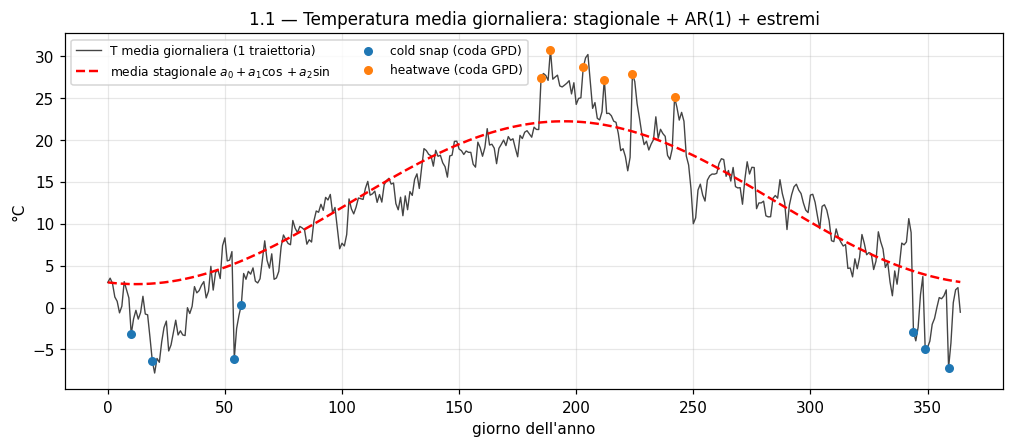

In [3]:
gg = np.arange(365)
seasonal = thermal.harmonic.evaluate(gg)

fig, ax = plt.subplots()
ax.plot(gg, daily_means, lw=0.9, color="#444", label="T media giornaliera (1 traiettoria)")
ax.plot(gg, seasonal, "r--", lw=1.6, label=r"media stagionale $a_0+a_1\cos+a_2\sin$")
ax.scatter(eventi.lower_event_days, daily_means[eventi.lower_event_days],
           c="tab:blue", s=24, zorder=5, label="cold snap (coda GPD)")
ax.scatter(eventi.upper_event_days, daily_means[eventi.upper_event_days],
           c="tab:orange", s=24, zorder=5, label="heatwave (coda GPD)")
ax.set_xlabel("giorno dell'anno"); ax.set_ylabel("°C")
ax.set_title("1.1 — Temperatura media giornaliera: stagionale + AR(1) + estremi")
ax.legend(ncol=2, fontsize=8)
plt.show()

**1.2 — Il profilo diurno orario.** `to_hourly()` solleva la media giornaliera
con una cosinusoide: stessa media, ma con il ciclo giorno/notte. In estate
l'escursione è più ampia (`t_amplitude_c` maggiore).

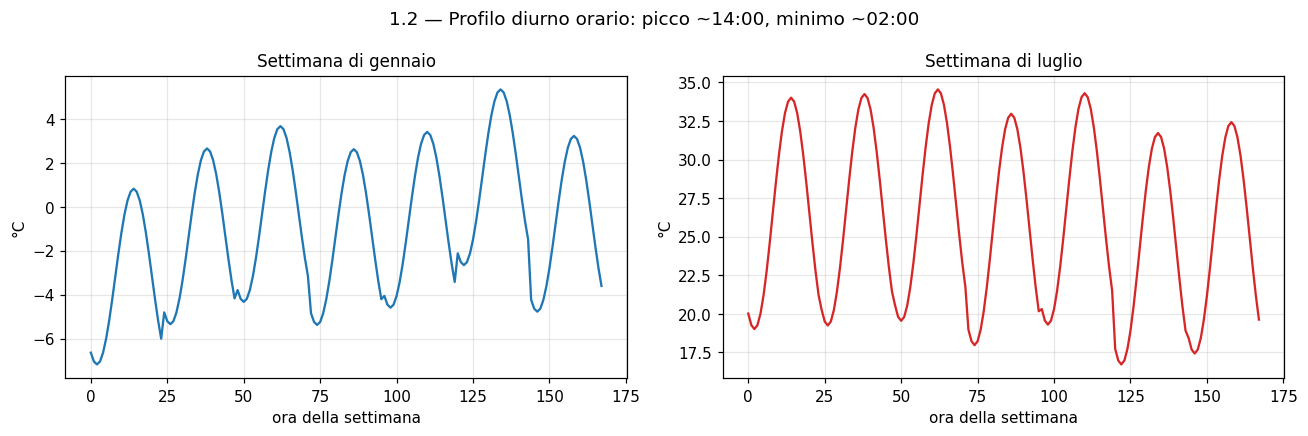

In [4]:
def settimana(series_h, giorno_inizio):
    s = giorno_inizio * 24
    return np.arange(24 * 7), series_h[s:s + 24 * 7]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x, w = settimana(T_amb_hourly, 10);  ax[0].plot(x, w, color="tab:blue"); ax[0].set_title("Settimana di gennaio")
x, s = settimana(T_amb_hourly, 195); ax[1].plot(x, s, color="tab:red");  ax[1].set_title("Settimana di luglio")
for a in ax:
    a.set_xlabel("ora della settimana"); a.set_ylabel("°C")
fig.suptitle("1.2 — Profilo diurno orario: picco ~14:00, minimo ~02:00")
fig.tight_layout()
plt.show()

**1.3 — Vista Monte Carlo (fan chart).** `simulate_temperature_preview` lancia
molti path indipendenti. A sinistra la banda di incertezza p05–p95 della media
*giornaliera*; a destra la distribuzione delle T *orarie* per mese (catturando
sia l'escursione diurna sia la variabilità tra path).

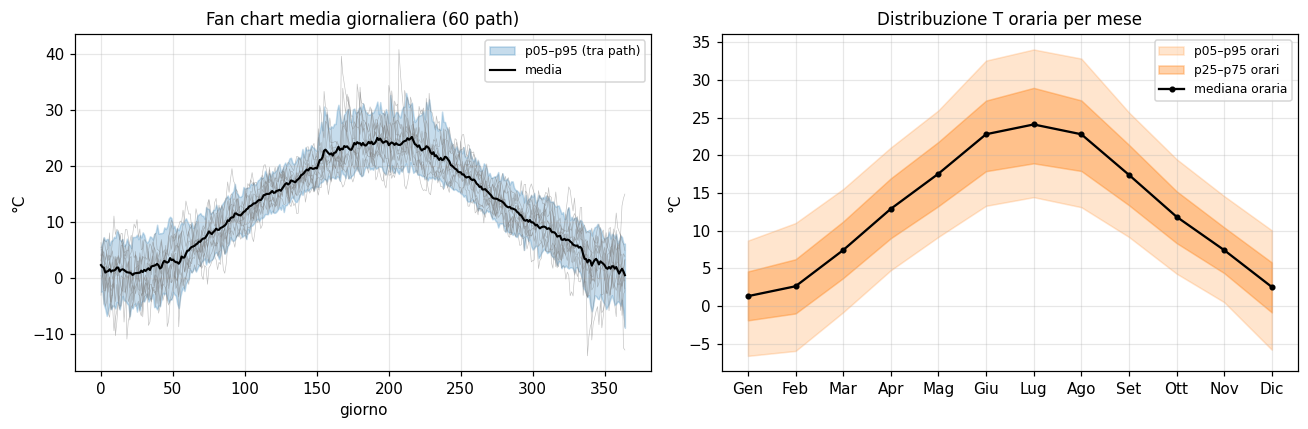

In [5]:
prev = simulate_temperature_preview(thermal, n_paths=60, n_years=1, seed=11)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].fill_between(prev.days, prev.p05_c, prev.p95_c, alpha=0.25, color="tab:blue", label="p05–p95 (tra path)")
for p in prev.sample_paths_c[:12]:
    ax[0].plot(prev.days, p, color="grey", lw=0.4, alpha=0.5)
ax[0].plot(prev.days, prev.mean_c, "k", lw=1.4, label="media")
ax[0].set_title("Fan chart media giornaliera (60 path)")
ax[0].set_xlabel("giorno"); ax[0].set_ylabel("°C"); ax[0].legend(fontsize=8)

x = np.arange(12)
ax[1].fill_between(x, prev.monthly_p05_c, prev.monthly_p95_c, alpha=0.20, color="tab:orange", label="p05–p95 orari")
ax[1].fill_between(x, prev.monthly_p25_c, prev.monthly_p75_c, alpha=0.35, color="tab:orange", label="p25–p75 orari")
ax[1].plot(x, prev.monthly_p50_c, "k-o", ms=3, label="mediana oraria")
ax[1].set_xticks(x); ax[1].set_xticklabels(MESI)
ax[1].set_title("Distribuzione T oraria per mese"); ax[1].set_ylabel("°C"); ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 2 · Modello elettrico — produzione PV in funzione della temperatura

Il modulo [`electrical.py`](../sim_stochastic_pv/simulation/electrical.py)
(`ElectricalModel`, opt-in di Fase 16) aggiunge realismo elettrico orario:

1. **Temperatura di cella** (relazione NOCT) — la cella è più calda dell'aria
   quando c'è sole:
   $$T_{cell} = T_{amb} + \frac{NOCT - 20}{800}\, G_{POA}$$
2. **Tensione di stringa** col coefficiente termico del datasheet:
   $$V(T) = V_{STC}\,\Big(1 + \tfrac{\beta}{100}(T_{cell}-25)\Big)\qquad V_{string}=N\cdot V$$
   A **freddo** $V_{oc}$ **sale**: rischio di superare `v_dc_max` → shutdown.
3. **Derating termico di potenza** (con $\gamma<0$, a caldo si produce meno):
   $$P \cdot \Big(1 + \tfrac{\gamma}{100}(T_{cell}-25)\Big)$$
4. **Finestra MPPT** — fuori da `[v_mppt_min, v_mppt_max]` la potenza è derata.

Usiamo il pannello **Longi LR5-72HPH-540M** e l'inverter **SMA Sunny Boy 5.0**
(entrambi dal seed catalog), con una stringa **ben dimensionata da 10 moduli**.
La produzione PV oraria arriva dal `SolarModel` reale (clima di Pavullo).

In [6]:
from sim_stochastic_pv.simulation.electrical import (
    PanelElectricalSpecs, InverterElectricalSpecs, PvString, ElectricalModel,
    cell_temperature_c, v_string_at_cell_temperature, STC_TEMPERATURE_C,
)
from sim_stochastic_pv.simulation.solar import SolarModel, make_default_solar_params_for_pavullo

panel = PanelElectricalSpecs(
    power_w=540.0, v_oc_stc_v=49.5, v_mpp_stc_v=41.5, i_sc_stc_a=13.92, i_mpp_stc_a=13.02,
    n_cells_series=144, beta_voc_pct_per_c=-0.27, gamma_pmax_pct_per_c=-0.34, noct_c=45.0,
)
inverter = InverterElectricalSpecs(
    v_dc_min_v=100.0, v_dc_max_v=600.0, v_mppt_min_v=175.0, v_mppt_max_v=500.0, n_mppt_trackers=2,
)

n_str = 10  # moduli in serie nella stringa (ben dimensionata: V_oc STC = 495 V < 600 V)
solar = SolarModel(
    pv_kwp=n_str * panel.power_w / 1000.0,
    month_params=make_default_solar_params_for_pavullo(), degradation_per_year=0.007,
)
month_for_day = np.asarray(month_of_year(np.arange(365) % 365))
year_for_day = np.zeros(365, dtype=int)
daily_pv = solar.simulate_daily_energy(1, month_for_day, year_for_day, np.random.default_rng(3))
pv_dc_kw = np.concatenate([solar.daily_profile_kwh(e) for e in daily_pv])   # (8760,) kW

nameplate_kw = n_str * panel.power_w / 1000.0
# proxy di irradianza usato internamente dal modello: P_dc/nameplate * 1000 W/m²
poa_proxy = 1000.0 * pv_dc_kw / nameplate_kw

print(f"Stringa: {n_str} moduli → {nameplate_kw:.2f} kWp | V_oc STC stringa {n_str * panel.v_oc_stc_v:.0f} V")
print(f"Produzione naive (pre-modello elettrico): {pv_dc_kw.sum():.0f} kWh/anno")

Stringa: 10 moduli → 5.40 kWp | V_oc STC stringa 495 V
Produzione naive (pre-modello elettrico): 5600 kWh/anno


**2.1 — Temperatura di cella (NOCT).** A 1000 W/m² la cella supera i 50 °C anche
con aria a 20 °C; in una giornata di luglio la cella sta ben sopra i 60 °C.

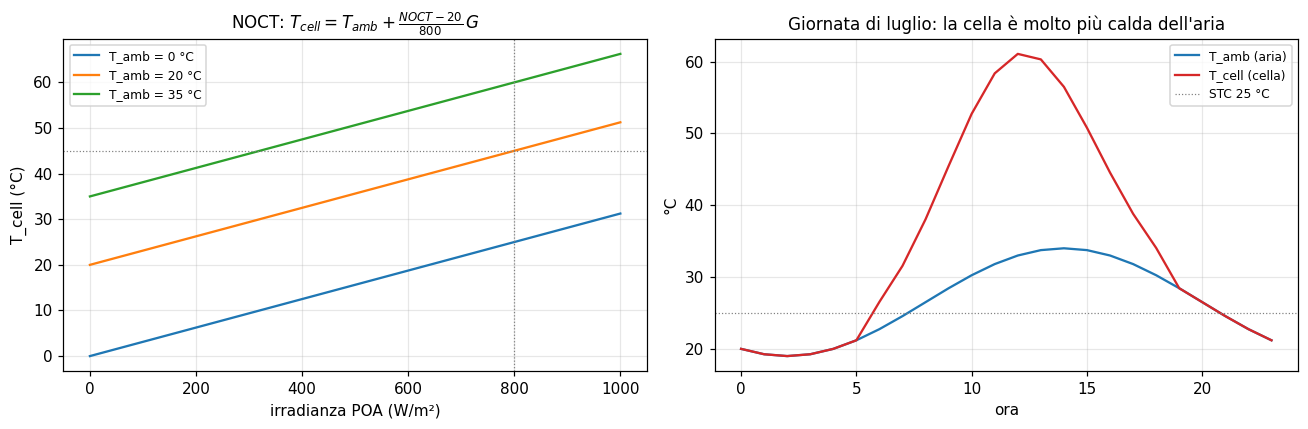

Luglio, ore 12: T_amb 33.0 °C → T_cell 61.1 °C


In [7]:
G = np.linspace(0, 1000, 100)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for ta in (0, 20, 35):
    ax[0].plot(G, cell_temperature_c(ta, G, panel.noct_c), label=f"T_amb = {ta} °C")
ax[0].axvline(800, color="grey", ls=":", lw=0.8); ax[0].axhline(panel.noct_c, color="grey", ls=":", lw=0.8)
ax[0].set_title(r"NOCT: $T_{cell}=T_{amb}+\frac{NOCT-20}{800}\,G$")
ax[0].set_xlabel("irradianza POA (W/m²)"); ax[0].set_ylabel("T_cell (°C)"); ax[0].legend(fontsize=8)

s = 195 * 24
amb_day = T_amb_hourly[s:s + 24]
tcell_day = cell_temperature_c(amb_day, poa_proxy[s:s + 24], panel.noct_c)
ax[1].plot(range(24), amb_day, label="T_amb (aria)")
ax[1].plot(range(24), tcell_day, color="tab:red", label="T_cell (cella)")
ax[1].axhline(STC_TEMPERATURE_C, color="grey", ls=":", lw=0.8, label="STC 25 °C")
ax[1].set_title("Giornata di luglio: la cella è molto più calda dell'aria")
ax[1].set_xlabel("ora"); ax[1].set_ylabel("°C"); ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()
print(f"Luglio, ore 12: T_amb {amb_day[12]:.1f} °C → T_cell {tcell_day[12]:.1f} °C")

**2.2 — I due effetti della temperatura.** A sinistra il **derating di potenza**
($\gamma$): a 65 °C di cella si perde ~14% di potenza. A destra la **tensione di
circuito aperto** $V_{oc}$ in funzione di $T_{cell}$ per tre dimensioni di
stringa: è la classica **regola di dimensionamento** — la $V_{oc}$ alla cella più
fredda attesa deve restare sotto `v_dc_max`. La stringa da 12 moduli sfonda il
limite, la 11 è al pelo, la 10 è sicura.

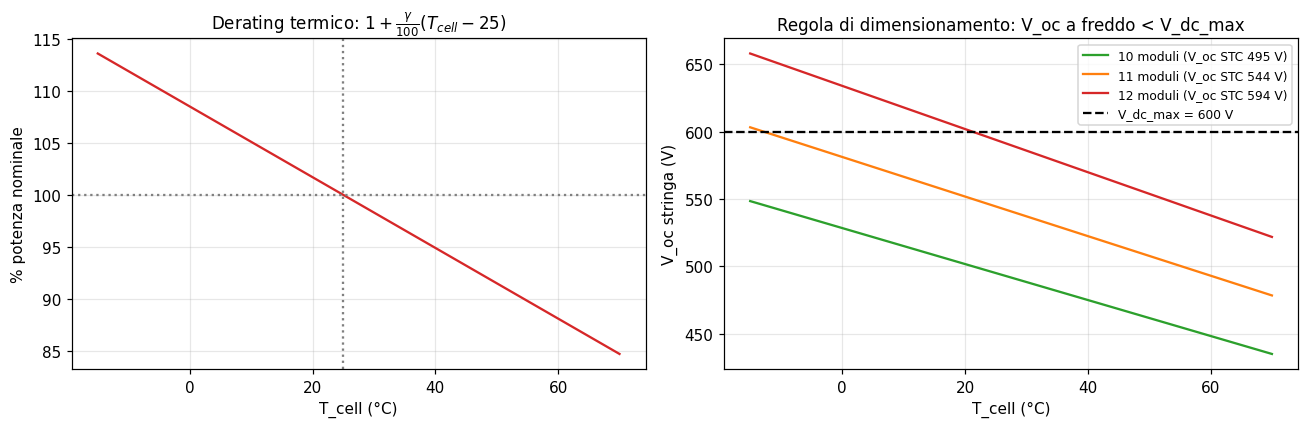

In [8]:
tc = np.linspace(-15, 70, 120)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

factor = 1 + panel.gamma_pmax_pct_per_c / 100 * (tc - 25)
ax[0].plot(tc, 100 * factor, color="tab:red")
ax[0].axhline(100, color="grey", ls=":"); ax[0].axvline(25, color="grey", ls=":")
ax[0].set_title(r"Derating termico: $1+\frac{\gamma}{100}(T_{cell}-25)$")
ax[0].set_xlabel("T_cell (°C)"); ax[0].set_ylabel("% potenza nominale")

for ns, c in ((10, "tab:green"), (11, "tab:orange"), (12, "tab:red")):
    voc = v_string_at_cell_temperature(panel.v_mpp_stc_v, panel.v_oc_stc_v,
                                       panel.beta_voc_pct_per_c, ns, tc, operating=False)
    ax[1].plot(tc, voc, color=c, label=f"{ns} moduli (V_oc STC {ns * panel.v_oc_stc_v:.0f} V)")
ax[1].axhline(inverter.v_dc_max_v, color="k", ls="--", label="V_dc_max = 600 V")
ax[1].set_title("Regola di dimensionamento: V_oc a freddo < V_dc_max")
ax[1].set_xlabel("T_cell (°C)"); ax[1].set_ylabel("V_oc stringa (V)"); ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

**2.3 — Effetto sull'anno intero.** Passiamo la produzione naive e la T ambiente
oraria a `ElectricalModel.apply_to_pv_dc`. Con la stringa da 10 moduli la perdita
è ~3% l'anno, **concentrata in estate** (derating termico), senza overvoltage.

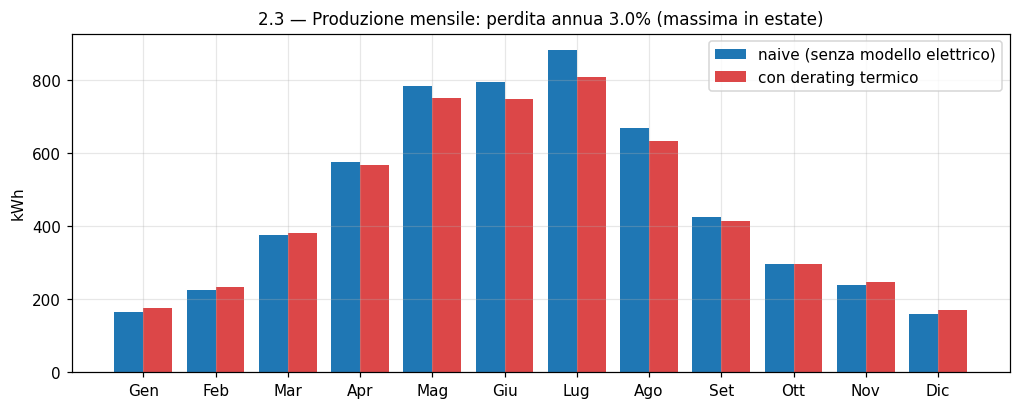

overvoltage           0 h/anno
fuori finestra MPPT      0 h/anno
V_string picco      544 V (limite 600)
V_string minimo     370 V (limite MPPT 175)


In [9]:
model_el = ElectricalModel(
    panel=panel, inverter=inverter,
    strings=[PvString(n_panels=n_str, tilt_degrees=30, azimuth_degrees=180)], n_years=1,
)
pv_adj, kpi = model_el.apply_to_pv_dc(pv_dc_kw, T_amb_hourly)

hrs_month = np.repeat(month_for_day, 24)
naive_m = np.array([pv_dc_kw[hrs_month == m].sum() for m in range(12)])
adj_m = np.array([pv_adj[hrs_month == m].sum() for m in range(12)])

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(12); wbar = 0.4
ax.bar(x - wbar / 2, naive_m, wbar, label="naive (senza modello elettrico)")
ax.bar(x + wbar / 2, adj_m, wbar, color="tab:red", alpha=0.85, label="con derating termico")
ax.set_xticks(x); ax.set_xticklabels(MESI); ax.set_ylabel("kWh")
loss = 100 * (1 - pv_adj.sum() / pv_dc_kw.sum())
ax.set_title(f"2.3 — Produzione mensile: perdita annua {loss:.1f}% (massima in estate)")
ax.legend()
plt.show()

print(f"overvoltage      {kpi.hours_dc_overvoltage_per_year:6.0f} h/anno")
print(f"fuori finestra MPPT {kpi.hours_outside_mppt_per_year:6.0f} h/anno")
print(f"V_string picco   {kpi.peak_v_string_v:6.0f} V (limite {inverter.v_dc_max_v:.0f})")
print(f"V_string minimo  {kpi.min_v_string_v:6.0f} V (limite MPPT {inverter.v_mppt_min_v:.0f})")

**2.4 — Esempio-cautela: stringa sovradimensionata (12 moduli).** Stessa coppia
pannello/inverter ma con `V_oc STC = 594 V` (margine quasi nullo sui 600 V):
nelle ore fredde la $V_{oc}$ sfonda il limite e l'inverter si spegne, con perdita
annua enorme. Il contatore di overvoltage include anche le ore notturne a
circuito aperto: è una **bandiera di rischio hardware**, non solo di energia.

In [10]:
bad = ElectricalModel(panel=panel, inverter=inverter, strings=[PvString(n_panels=12)], n_years=1)
solar12 = SolarModel(pv_kwp=12 * panel.power_w / 1000.0,
                     month_params=make_default_solar_params_for_pavullo(), degradation_per_year=0.007)
pv12 = np.concatenate([solar12.daily_profile_kwh(e)
                       for e in solar12.simulate_daily_energy(1, month_for_day, year_for_day, np.random.default_rng(3))])
pv12_adj, kpi12 = bad.apply_to_pv_dc(pv12, T_amb_hourly)

print("STRINGA SOVRADIMENSIONATA — 12 moduli, V_oc STC 594 V:")
print(f"  perdita annua   {100 * (1 - pv12_adj.sum() / pv12.sum()):.1f} %")
print(f"  overvoltage     {kpi12.hours_dc_overvoltage_per_year:.0f} h/anno")
print(f"  V_string picco  {kpi12.peak_v_string_v:.0f} V  >  {inverter.v_dc_max_v:.0f} V (limite superato)")
print("→ confronto con i 10 moduli sopra: il dimensionamento della stringa conta quanto il pannello.")

STRINGA SOVRADIMENSIONATA — 12 moduli, V_oc STC 594 V:
  perdita annua   26.7 %
  overvoltage     6388 h/anno
  V_string picco  653 V  >  600 V (limite superato)
→ confronto con i 10 moduli sopra: il dimensionamento della stringa conta quanto il pannello.


## 3 · Temperatura in casa — modello HVAC (casa isolata male)

Il modulo [`thermal_load.py`](../sim_stochastic_pv/simulation/thermal_load.py)
(`HvacController`, Fase 17) modella la casa come un **RC monozona** con una pompa
di calore. L'edificio è caratterizzato dalla trasmittanza d'involucro `UA`
(W/°C), che dipende dal **preset di isolamento**:

| preset | W/°C/m² | tipologia |
|--------|---------|-----------|
| `poor` | **2.5** | anni '60–'70, muri sottili, vetri singoli (← *casa isolata male*) |
| `standard` | 1.5 | anni '90–2000, doppi vetri + intercapedine |
| `good` | 0.8 | NZEB / Classe A, cappotto continuo, tripli vetri |

**Modalità steady-state** (quella implementata): assume che la casa stia *al
setpoint* e calcola la potenza richiesta:
$$P_{th} = UA\,(T_{set}-T_{amb}),\qquad P_{el}=\frac{P_{th}}{COP}$$
capata a `p_elec_max_kw`; le ore in cui serve più potenza del massimo sono
contate come `comfort_breach_hours` (la pompa è sottodimensionata).

Casa di **120 m²**, pompa **2.0 kW** elettrici, setpoint 20 °C (inverno) / 26 °C
(estate).

In [11]:
from sim_stochastic_pv.simulation.thermal_load import (
    ThermalLoadConfig, HouseThermalConfig, HeatPumpConfig, SetpointConfig,
    HvacController, INSULATION_PRESETS,
)
print("Preset isolamento (W/°C/m²):", INSULATION_PRESETS)

def configura_casa(preset, area_m2=120.0, p_elec_max_kw=2.0):
    return ThermalLoadConfig(
        enabled=True,
        house=HouseThermalConfig(
            floor_area_m2=area_m2, insulation_preset=preset,
            internal_gains_kw=0.3,  # guadagni gratuiti; contano solo in dinamico
        ),
        heat_pump=HeatPumpConfig(cop_heating=3.5, cop_cooling=3.0, p_elec_max_kw=p_elec_max_kw),
        setpoint=SetpointConfig(t_setpoint_heating_c=20.0, t_setpoint_cooling_c=26.0),
    )

for p in ("poor", "standard", "good"):
    print(f"  {p:9s}: UA = {configura_casa(p).house.ua_kw_per_c:.3f} kW/°C")

Preset isolamento (W/°C/m²): {'poor': 2.5, 'standard': 1.5, 'good': 0.8}
  poor     : UA = 0.300 kW/°C
  standard : UA = 0.180 kW/°C
  good     : UA = 0.096 kW/°C


**3.1 — Carico elettrico HVAC annuo per livello di isolamento.** L'isolamento è
il driver numero uno della bolletta termica: la casa `poor` consuma **~3×** la
casa `good` e richiede un picco di potenza molto più alto. Le `comfort_breach`
indicano le ore in cui la pompa è già al massimo e non basta.

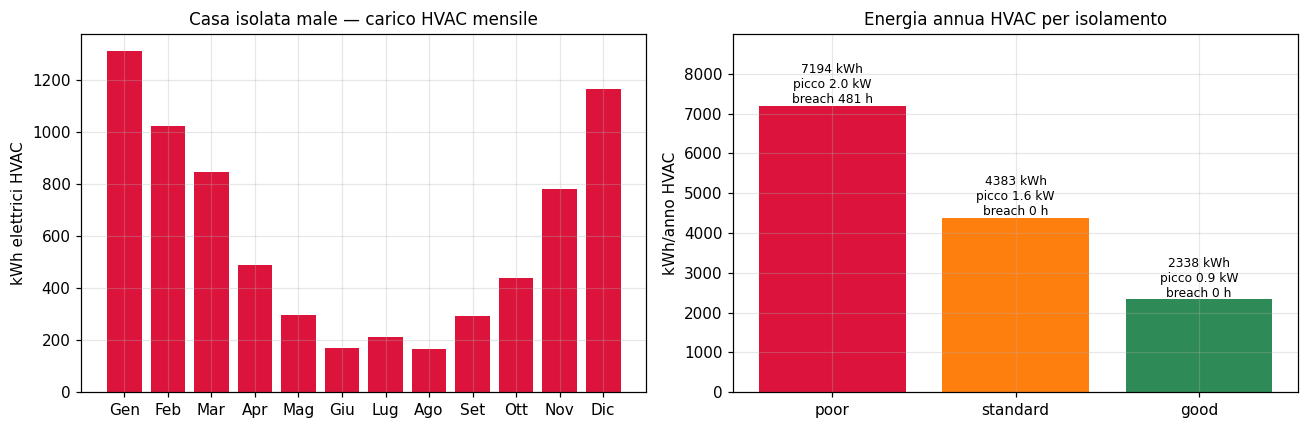

In [12]:
risultati = {}
for p in ("poor", "standard", "good"):
    p_elec_h, kpis = HvacController(configura_casa(p)).compute_hourly_p_elec_kw(T_amb_hourly)
    risultati[p] = (p_elec_h, kpis)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

hvac_mese_poor = np.array([risultati["poor"][0][hrs_month == m].sum() for m in range(12)])
ax[0].bar(np.arange(12), hvac_mese_poor, color="crimson")
ax[0].set_xticks(np.arange(12)); ax[0].set_xticklabels(MESI)
ax[0].set_ylabel("kWh elettrici HVAC"); ax[0].set_title("Casa isolata male — carico HVAC mensile")

labels = ["poor", "standard", "good"]
kwh = [risultati[p][1].hvac_kwh_annual for p in labels]
ax[1].bar(np.arange(3), kwh, color=["crimson", "tab:orange", "seagreen"])
for i, p in enumerate(labels):
    k = risultati[p][1]
    ax[1].text(i, kwh[i] + 60, f"{k.hvac_kwh_annual:.0f} kWh\npicco {k.p_elec_hvac_peak_kw:.1f} kW\nbreach {k.comfort_breach_hours_per_year:.0f} h",
               ha="center", fontsize=8)
ax[1].set_xticks(np.arange(3)); ax[1].set_xticklabels(labels)
ax[1].set_ylabel("kWh/anno HVAC"); ax[1].set_title("Energia annua HVAC per isolamento")
ax[1].set_ylim(0, max(kwh) * 1.25)
fig.tight_layout()
plt.show()

**3.2 — Ma quanto fa freddo *dentro*?** Il modello steady-state assume la casa
sempre al setpoint: per **vedere la temperatura interna** durante un'ondata di
freddo serve la **modalità dinamica RC** (`thermal_load.dynamic=True`),
implementata in libreria nella **Fase 18**. Risolve il bilancio termico con un
integratore di **Eulero implicito** a passo orario, usando esattamente gli
stessi parametri della config (`UA`, capacità termica `C`, `COP`, `p_elec_max`,
guadagni interni):

$$C\,\frac{dT_{in}}{dt} = \underbrace{Q_{HVAC}}_{\le\,P_{el,max}\cdot COP} + Q_{interni} - \underbrace{UA\,(T_{in}-T_{out})}_{\text{dispersioni}}$$

Il termostato (*deadbeat*) chiede la potenza che riporterebbe la casa al
setpoint, ma la pompa è **limitata** a `p_elec_max`: quando le dispersioni
superano quel tetto, la temperatura interna **scende sotto il setpoint**. La
cella sotto chiama direttamente `HvacController` (con `dynamic=True`) e legge la
traiettoria da `controller.last_indoor_temp_c` — niente più ricostruzione a
mano.

In [13]:
from dataclasses import replace


def simula_temperatura_interna_rc(t_out_h, cfg):
    """Temperatura interna oraria via la modalità dinamica RC della libreria.

    Attiva il flag ``dynamic`` sulla config HVAC e delega a
    :class:`HvacController` (integratore a Eulero implicito, Fase 18), poi
    restituisce la traiettoria di temperatura interna e l'assorbimento
    elettrico ora per ora.

    Args:
        t_out_h: T esterna oraria (°C), shape ``(n_ore,)``.
        cfg: ``ThermalLoadConfig`` (UA, capacità, COP, p_elec_max, setpoint,
            guadagni interni). Il flag ``dynamic`` viene forzato a True qui.

    Returns:
        ``(T_interna_c, P_elec_kw)``: due array shape ``(n_ore,)``.
    """
    controller = HvacController(replace(cfg, dynamic=True))
    p_elec_kw, _ = controller.compute_hourly_p_elec_kw(t_out_h)
    return controller.last_indoor_temp_c, p_elec_kw

**3.3 — La temperatura in casa durante la settimana più fredda.** Individuiamo la
settimana più fredda dell'anno simulato e confrontiamo casa `poor` e `good`.

poor : T interna min 16.7 °C | ore sotto 19 °C  99 | P_elec picco 2.00 kW
good : T interna min 20.0 °C | ore sotto 19 °C   0 | P_elec picco 0.79 kW


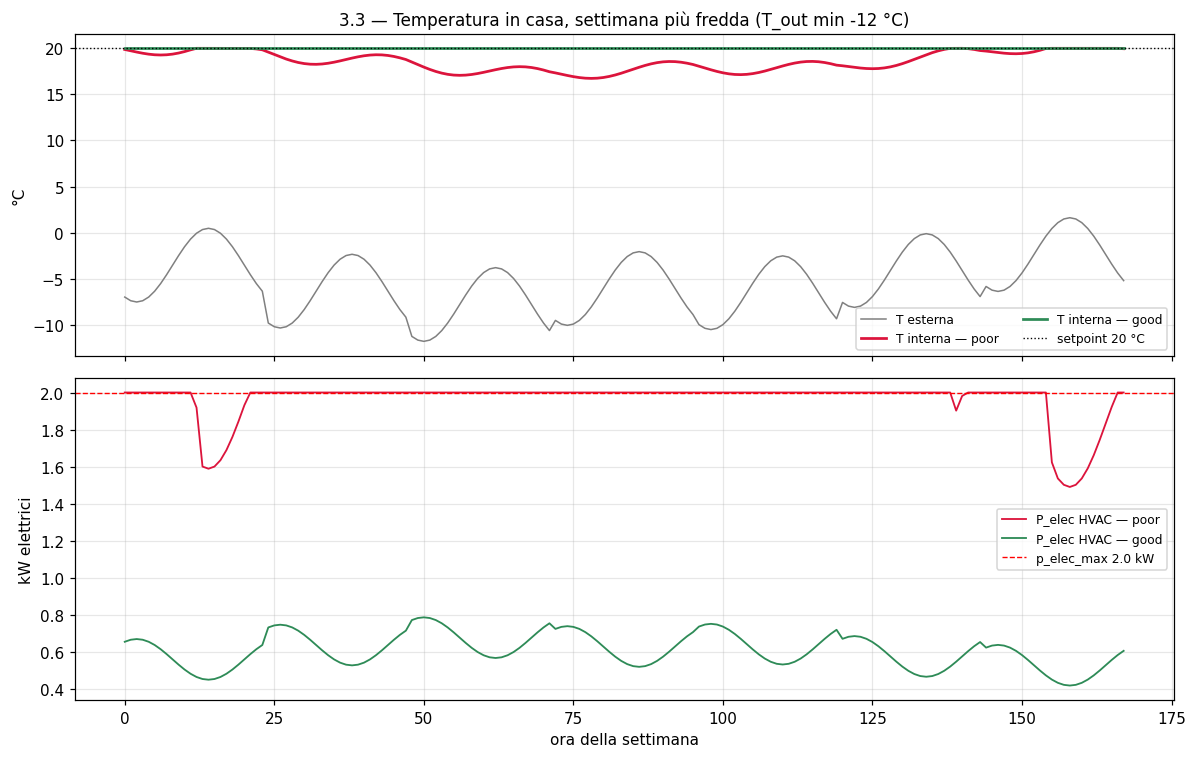

In [14]:
medie_settimanali = [daily_means[i:i + 7].mean() for i in range(0, 365 - 7)]
cold_start = int(np.argmin(medie_settimanali))
s = cold_start * 24
t_out_week = T_amb_hourly[s:s + 24 * 7]

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].plot(t_out_week, color="grey", lw=1.0, label="T esterna")
for p, c in (("poor", "crimson"), ("good", "seagreen")):
    Tin, Pe = simula_temperatura_interna_rc(t_out_week, configura_casa(p))
    ax[0].plot(Tin, color=c, lw=1.8, label=f"T interna — {p}")
    ax[1].plot(Pe, color=c, lw=1.2, label=f"P_elec HVAC — {p}")
    print(f"{p:5s}: T interna min {Tin.min():.1f} °C | ore sotto 19 °C {(Tin < 19).sum():3d} | P_elec picco {Pe.max():.2f} kW")

ax[0].axhline(20, color="k", ls=":", lw=0.9, label="setpoint 20 °C")
ax[0].set_ylabel("°C"); ax[0].legend(ncol=2, fontsize=8)
ax[0].set_title(f"3.3 — Temperatura in casa, settimana più fredda (T_out min {t_out_week.min():.0f} °C)")
ax[1].axhline(2.0, color="r", ls="--", lw=0.9, label="p_elec_max 2.0 kW")
ax[1].set_ylabel("kW elettrici"); ax[1].set_xlabel("ora della settimana"); ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

### In sintesi

- **Modello termico** (`ThermalModel`): la T esterna nasce da media stagionale +
  persistenza AR(1) + estremi GPD, poi sollevata in orario col profilo diurno.
  È l'**unica sorgente** di temperatura per gli altri due modelli.
- **Modello elettrico** (`ElectricalModel`): la stessa T ambiente determina la T
  di cella (NOCT) → derating di potenza estivo (`gamma`) e rischio overvoltage
  invernale (`beta` su `V_oc`). Il **dimensionamento della stringa** rispetto a
  `v_dc_max` è critico (10 vs 12 moduli).
- **Modello casa** (`HvacController`): la T ambiente guida il carico della pompa
  di calore. Con **isolamento scadente** (`poor`) i consumi annui triplicano e,
  durante un'ondata di freddo, la pompa satura e la casa **non tiene i 20 °C** —
  cosa che la modalità dinamica RC (`dynamic=True`, **Fase 18**) rende visibile,
  mentre la
  steady-state la riassume nelle `comfort_breach_hours`.

Riferimenti: ROADMAP Fasi **15** (termico), **16** (elettrico), **17** (HVAC),
**18** (dinamica RC / temperatura interna); `energy_simulator.py` per il
cablaggio nel Monte Carlo.